In [1]:
import numpy as np              # load numerical module
import matplotlib.pyplot as plt # load plotting module
import astropy.io.fits as fits
import gaussian as g
import radprof as R
import disk as d

### Reading: Howell Ch 6

 ## What is Spectroscopy?: 
- *Photometry* answers: How bright?
    - Specifically: How bright in a certain *wavelength bandpass*?
    - Usually done with filters on an array
- *Spectral resolving power* $R = \frac{\lambda}{\Delta\lambda}$~ 4--5.
    - For example, a 100 nm-wide filter at $\lambda$=500 nm.
- Much can be done very efficiently this way:
    - Stellar temperatures
    - Time-variable phenomena like variable stars, exoplanet transits, simple cloud mapping etc



<img src="nasa_sol_spec.png" width=400>

- *Spectroscopy* answers: How bright as a function of wavelength?
    - samples the emitted energy distribution from an astronomical source in wavelength bins of size $\Delta\lambda$.
    
- $R = \frac{\lambda}{\Delta\lambda}$~ 100—1,000,000.

- Gives a more detailed understanding of the physics governing the object we study 
    - what is the nature of the exoplanet atmosphere, what is the nature of clouds and at what pressures are they, what is the nature of a small body surface etc

- Photometry measures one bandpass at a time.
- Spectroscopy measures many (10--10,000) small bandpasses simultaneously!


- We can do spectroscopy of:
    - point sources (objects whose angular size is determined by the seeing disk or instrumental resolution)
    - extended objects
    
        - Can you think of examples for each category?



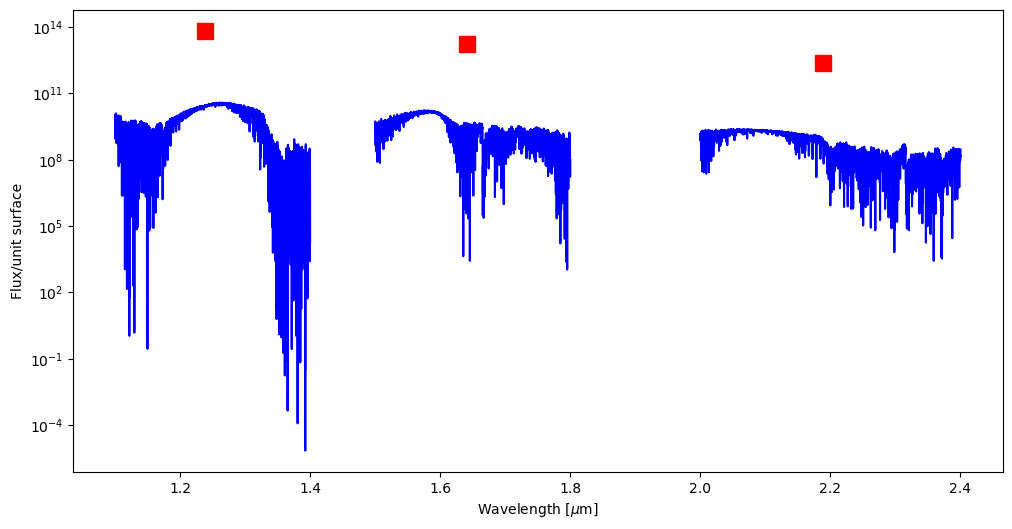

In [3]:
#get data from sample spec:
dat_example = np.loadtxt('sample_spect.spec',skiprows = 2)
wav, f      = dat_example[ :,0 ], dat_example[ :,1 ]

#define J, H, K band edges for integration (assume a random 
# flat response function of your instrument):
lmin_j = 1.1
lmax_j = 1.4
lmin_h = 1.5
lmax_h = 1.8
lmin_k = 2.0
lmax_k = 2.4

#get lims in wav array:
l1_j   = np.max( np.where( wav >= lmin_j ) )  #note that wav is in decreasing order that's why
l2_j   = np.max( np.where( wav >= lmax_j ) )  #I use a weird structure here
l1_h   = np.max( np.where( wav >= lmin_h ) )  
l2_h   = np.max( np.where( wav >= lmax_h ) )
l1_k   = np.max( np.where( wav >= lmin_k ) )  
l2_k   = np.max( np.where( wav >= lmax_k ) )

#plot the full-blown high res spectrum in J/H/K and the photometry:

plt.figure(figsize = (12, 6))
plt.semilogy( wav[ l2_j: l1_j ], f[ l2_j: l1_j ] , 'b')
plt.semilogy( wav[ l2_h: l1_h ], f[ l2_h: l1_h ] , 'b')
plt.semilogy( wav[ l2_k: l1_k ], f[ l2_k: l1_k ] , 'b')


#for the photometry I assume here a flat (not realistic) filter
plt.plot( np.mean( wav[ l2_j: l1_j ] ), np.sum( f[ l2_j: l1_j ] ), 'r', 
         marker = 's', markersize = 12)
plt.plot( np.mean( wav[ l2_h: l1_h ] ), np.sum( f[ l2_h: l1_h ] ), 'r', 
         marker = 's', markersize = 12)
plt.plot( np.mean( wav[ l2_k: l1_k ] ), np.sum(  f[ l2_k: l1_k ] ), 'r', 
         marker = 's', markersize = 12)


plt.xlabel('Wavelength [$\mu$m]')
dm = plt.ylabel('Flux/unit surface')


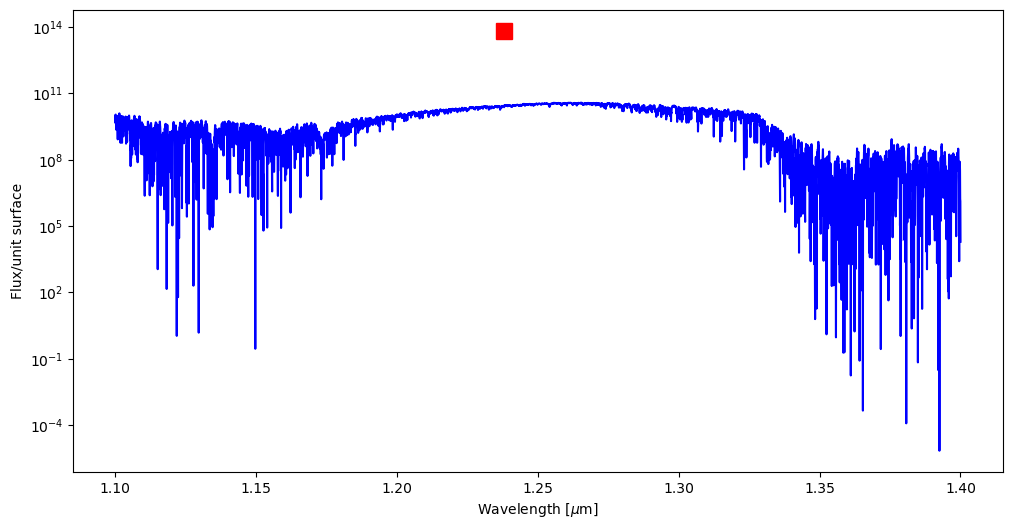

In [4]:
#plot the J only:

plt.figure(figsize = (12, 6))
plt.semilogy( wav[ l2_j: l1_j ], f[ l2_j: l1_j ] , 'b')


plt.plot( np.mean( wav[ l2_j: l1_j ] ), np.sum( f[ l2_j: l1_j ] ), 'r', 
         marker = 's', markersize = 12)

plt.xlabel('Wavelength [$\mu$m]')
dm = plt.ylabel('Flux/unit surface')

### remember, that for more realistic photometry/spectroscopy models that you can compare with RL observations you can use filters from [SVO](http://svo2.cab.inta-csic.es/svo/theory/fps3/index.php?id=JWST/NIRCam.F356W&&mode=browse&gname=JWST&gname2=NIRCam#filter)

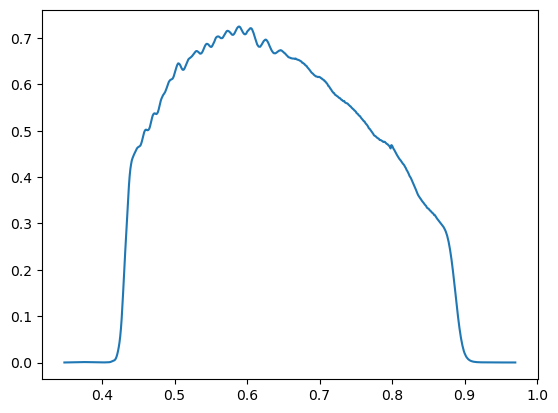

In [5]:
#e.g, Kepler/K2 photometry vs our simplified flat function from before:

k2   = np.loadtxt('Kepler_SVO2_filter.dat')
w_k2 = k2[ :,0 ] *1e-4
r_k2 = k2[ :,1 ]

#show response func

dm = plt.plot( w_k2, r_k2 )

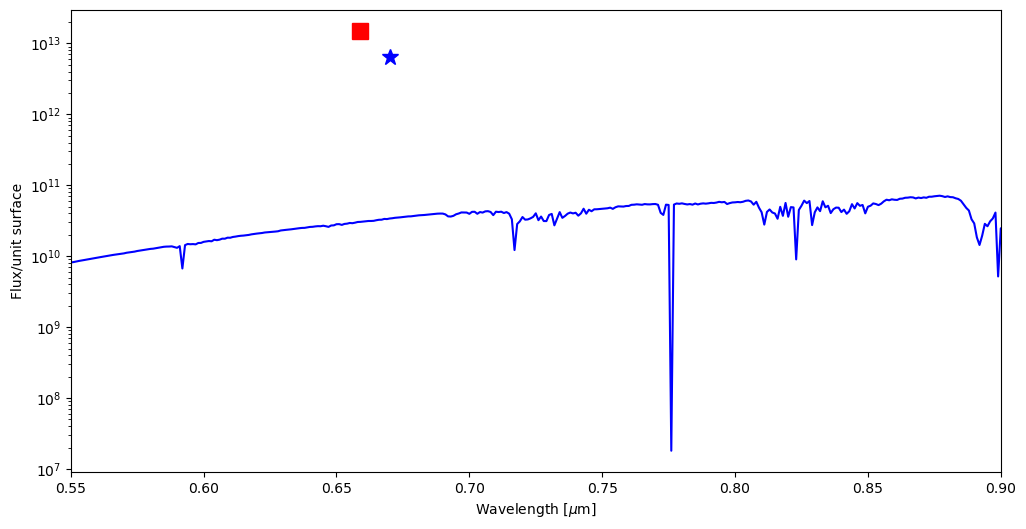

In [6]:
#plot photometry of the 2 methods:

lmin_k2 = 0.5
lmax_k2 = 0.9

#get lims in wav array:
l1_k2   = np.max( np.where( wav >= lmin_k2 ) )  #note that wav is in decreasing order that's why
l2_k2   = np.max( np.where( wav >= lmax_k2 ) )  #I use a weird structure here


#interpolate model to filter wav grid:
mod_int_k2  = np.interp( w_k2, np.flip( wav[ l2_k2: l1_k2 ],0 ), 
                        np.flip( f[ l2_k2: l1_k2 ],0) )

#plot the full-blown high res spectrum in J/H/K and the photometry:

plt.figure(figsize = (12, 6))
plt.semilogy( w_k2, mod_int_k2 , 'b')

#get flat (wrong) photometry:
plt.plot( np.mean( w_k2 ), np.sum( mod_int_k2 ), 'r', 
         marker = 's', markersize = 12)

#get real one:


#get the total flux:
mod_filt_k2 = mod_int_k2 * r_k2
#sum to get photometry:
k2_photom   = np.sum( mod_filt_k2 )
#plot K/K2 photom:

plt.plot( 0.67, k2_photom, 'b', 
         marker = '*', markersize = 12)
plt.xlim(.55, .9)
plt.xlabel('Wavelength [$\mu$m]')
dm = plt.ylabel('Flux/unit surface')

## Spectroscopy Basics: 
- Use [dispersion](https://en.wikipedia.org/wiki/Dispersion_(optics)) to sort photons by wavelength
- This spreads a point source over a line
- Position on the line is related monotonically to wavelength


- JWST NIRSpec PRISM/CLEAR example for 2M2228 from ETC:
<img src="nirspec_scene.png" width=300>
<img src="nirspec_detector.png" width=350>
<img src="nirspec_spec.png" width=350>



- Dispersers:
    - [Prism](https://en.wikipedia.org/wiki/Dispersive_prism): e.g., [NIRSpec](ebb.nasa.gov/content/observatory/instruments/nirspec.html) PRISM/CLEAR
    - [Grating](https://en.wikipedia.org/wiki/Diffraction_grating) : e.g., NIRSpec mid and high R
    - [Grism](https://en.wikipedia.org/wiki/Grism) (prism with grating etched onto one or both surfaces) : e.g., [NIRISS](https://jwst-docs.stsci.edu/jwst-near-infrared-imager-and-slitless-spectrograph) Soss; extra benefit for bright objects


<img src="jwst_nirspec_transmission_gratings-02.png" width=550> 
<img src="soss_grism_spectra.png" width=550> 



## Overview of Spectroscopy: 
- Refraction: 
    - bending of light when going from medium 1 to medium 2
    - refractive index changing == propagation speed of light changes
    - Snell's law: $n_{1}\sin{\theta_{1}} = n_{2}\sin{\theta_{2}}$

        - $n_{x}$ are indices of refraction
        - $\theta_{x}$ are normal angles
        - $\theta_{1}$ and $n_{1}$ are (nearly) constant
        - $n_{2}$ varies strongly with $\lambda$
    - So, $\theta_{2}$ changes with $\lambda$
    
    - if 2 surfaces of glass are parallel, the emerging wave is parallel to incident one
        - otherwise incident and emerging wave will have different directions
    
<img src="glass_prisms.png" width=350>


- Dispersion occurs because of $n(\lambda)$ dependency; violet is bent the most, red the least

<img src="pinkfloyd.png" width=350> (Pink Floyd: Dark Side of the Moon)

    
- Prisms have low dispersion, $R=\frac{\lambda}{\Delta\lambda}<<1000$

    -$R$ is determined by PSF size: "true" spectrum convolved by PSF
    - BUT, we can pass light through a *slit* to reduce PSF (see below)



- Grism: <img src="niriss_soss_schem.png" width=350> ( [NIRISS Soss](https://iopscience.iop.org/article/10.1088/1538-3873/acd7a3/pdf) )



- Making an image with a telescope and aperture: <img src="telescope_focals_magnif.png" width=550> 

    - imaging

- vs making a spectrum with a spectroscope: <img src="telescope_spectr.png" width=550> 

    - PRISM/CLEAR; Soss

- Making an image with a telescope and slit: <img src="telescope_focals_magnif_slit.png" width=550> 

    - Keck LRIS
    
- vs making a spectrum with a spectroscope: 
    - low R: <img src="telescope_spectr_slit.png" width=550> 
    - higher R: <img src="telescope_spectr_slit_highR.png" width=550> 
    
    - [MIRI and NIRSpec](https://jwst-docs.stsci.edu/methods-and-roadmaps/jwst-slit-spectroscopy)


- Spectrograph optics
  - Discard light, but improve $R$
  - Avoid nearby objects contaminating spectrum
  - Can use mirrored slit, send rest of image to slit-viewing camera
  - Camera can guide exposure
  - Camera can monitor slit placement

## Apertures in spectroscopy

- imaging photometry: use an aperture to count up the counts. 
    - circular apperture is easy for 2D image

- spectrum: want to measure counts *but* have 2D array with 1D == $\lambda$
    - circular aperture doesn't make much sense
    - use a rectangular aperture

        - There are two main reasons for why a rectangular aperture is better.
            - in the $\lambda$ dimension, want as narrow an aperture as possible to not lose $\lambda$-resolution (ideally want an aperture that is just one pixel wide)

            - the aperture correction -- an important part of the imaging photometry process -- is not usually done in spectroscopy. Goal: get a spectrum with the relative fluxes.
            
- If you need know the absolute flux need get spectra of known reference stars
    - use the same aperture size with the reference stars as with their source of interest


- how tall should the aperture be? Depends on the kind of source you're looking at. 
    - point source, going as small an aperture as possible is good 
    - try to include as much of the point-source as possible, 
    - going too small means miss info from point source flux at some $\lambda$
    - going with too large means you include too many pixels with very few source photons and lots of noise photons$\rightarrow$lower S/N
    
    - goal: slit width set such that most of the PSF (of point source) passs through; *but* small enough to eliminate as much of the sky as possible from entering the spectrograph

## Slit Width and Resolving Power: 
- *Resolving power*: $R=\lambda/\Delta\lambda$
    - $\Delta\lambda$ is set by the slit width (your PSF): 
    A wider slit integrates over more wavelength
        - increases $\Delta\lambda$ and reduces $R$
    - Usually the slit is 3--10 pixels wide: want to overresolve pixel scale

- $R$ is related to the *dispersion*, $\frac{d\beta}{d\lambda}$: High dispersion is high resolving power and less *grasp* or *reach* (amount of spectrum fitting on the chip)
    - Deflection angle $\beta$ translates to distance in pixels in camera

- The spectral intensity $I_{i}$ in pixel $i$ is $$I_{i} = \int_{\lambda_\mathrm{pix}} I_{\lambda}\circ T_{\lambda} d\lambda$$, $$T_{\lambda} = {\rm PSF_{\lambda}} T_{\rm slit, \lambda}$$
    - $I_{\lambda}$ is the ideal spectrum, at infinite resolution
    - $T_{\rm slit, \lambda}$, the transmission fraction mapped to pixels, is the *resolution element*
        - It is a box function, 0 everywhere except for a flat-topped plateau equal to 1
        - The PSF will be truncated by $T_{\rm slit, \lambda}$<br><br>
    - If looking at stars, they may have higher-resolution spectra than the background
        - The star illuminates only the middle of the slit
        - The PSF of a star may be narrower than the width of the slit
        - The sky uniformly illuminates the slit
        - ~flat PSF, so, $T_{{\rm star}, \lambda}$ may be narrower and more peaked than $T_{{\rm sky}, \lambda}$


## Long-Slit Spectroscopic Extraction: 
- Slit usually covers entire detector  
- Star is only part of the slit
- Can get sky background spectrum next to star
- Extended objects bigger, may or may not fill slit


- Scan slit: spatial-spectral hypercube
    - for XPs: can also allow planet to rotate under slit

In [7]:
# AST5765 demo: long-slit spectrum extraction

# This demo dates from the early offerings of this course.
# 2017-11-07 0.2 jh@physics.ucf.edu Converted to Python3/PyDS9 #latter rm by TK

lsdat1 = fits.getdata('w00846.fit')  #OH- sky line for calibration
lsdat2 = fits.getdata('w00848.fit')  #obs
print(lsdat1.shape)
# it says (1, 256, 256), which is true but confuses ds9, so...
lsdat1.shape = lsdat1.shape[1:]
lsdat2.shape = lsdat2.shape[1:]

(1, 256, 256)


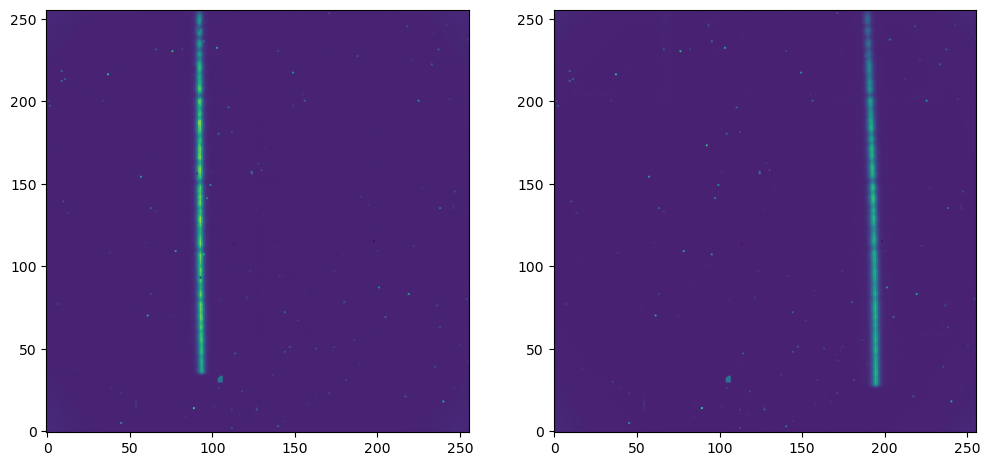

In [8]:
#see the data:
fig,ax = plt.subplots( 1,2, figsize = (12, 7) )
ax[0].imshow( lsdat1,origin = 'lower' )

dm = ax[1].imshow( lsdat2,origin = 'lower' )

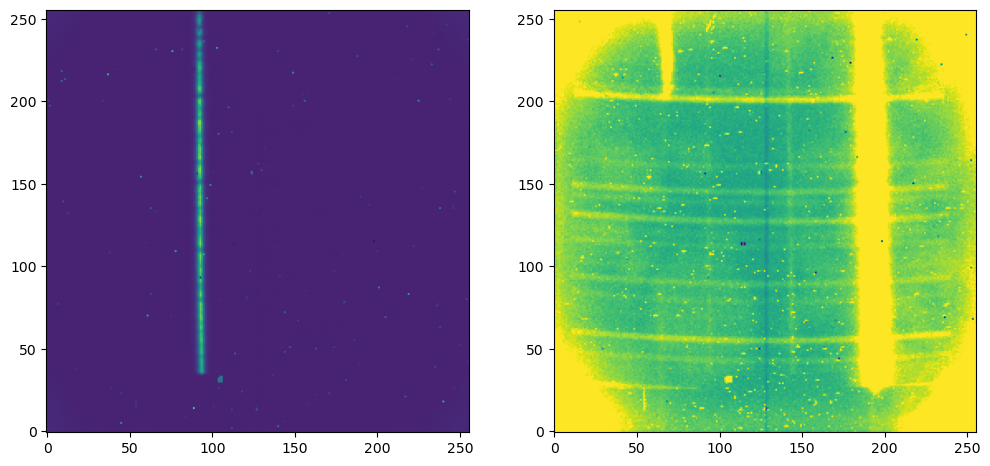

In [9]:
#get a zoomed-in image of 2:
fig,ax = plt.subplots( 1,2, figsize = (12, 7) )
ax[0].imshow( lsdat1 ,origin = 'lower')

dm = ax[1].imshow( np.clip( lsdat2, -1000, 1000) ,origin = 'lower')

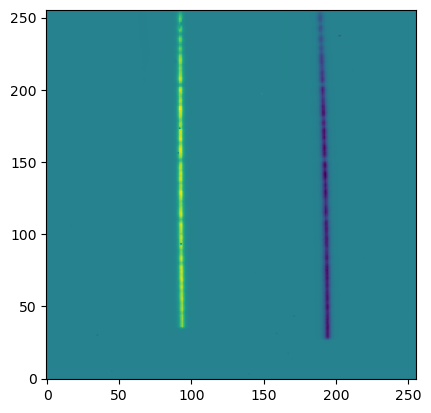

In [10]:
#plot the dif of the 2 images 
reddat = lsdat1 - lsdat2
dm = plt.imshow( reddat,origin = 'lower' )


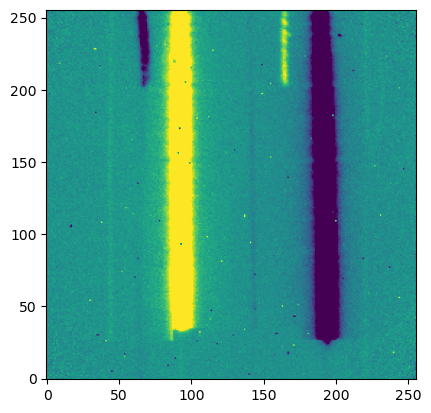

In [11]:
#and plot it zoomed-in

dm = plt.imshow( np.clip(reddat, -1000, 1000),origin = 'lower' )

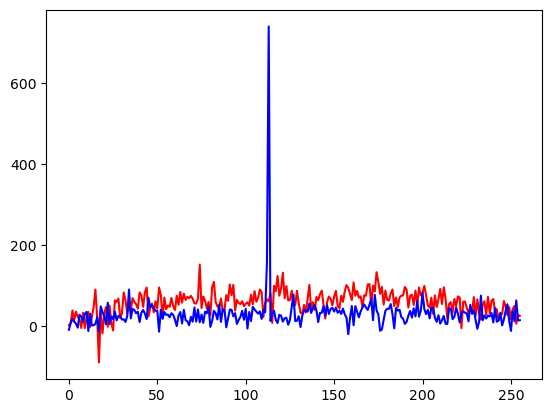

In [12]:
# column numbers for the sky and spectrum regions
skywid  = 10
skysep  = 37
spechw  = 35 // 2 # integer division desired
specctr = 93
sky1s   = specctr - skysep - skywid
sky1e   = specctr - skysep
specs   = specctr - spechw
spece   = specctr + spechw
sky2s   = specctr + skysep
sky2e   = specctr + skysep + skywid

# get per-pixel average background on both sides of spectrum
bg1     = np.mean(reddat[:, sky1s : sky1e], axis=1)
bg2     = np.mean(reddat[:, sky2s : sky2e], axis=1)
# get spectrum
spec    = np.sum( reddat[:, specs : spece], axis=1)
# get OH lines from raw image
ohlines = np.mean(lsdat1[:, sky1s : sky1e], axis=1)

# plot background, note internal reflection! (really should avoid or mask)
plt.plot(bg1, 'r')
dm = plt.plot(bg2,'b')

In [13]:
#sky1s, sky1e,sky2s , sky2e, specs , spece


In [14]:
#%matplotlib inline
#plt.imshow(lsdat1[:, sky1s : sky1e])

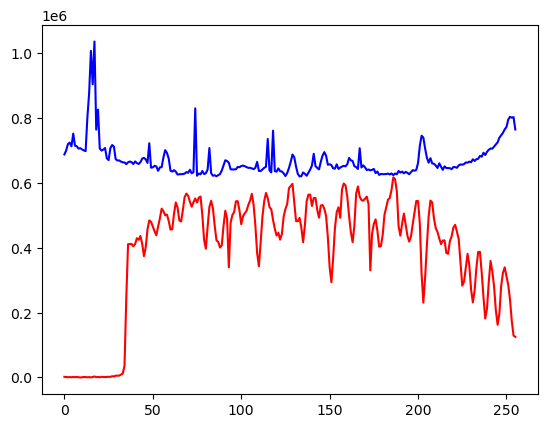

In [15]:
# the spectrum minus the background, with OH lines for reference
specminsky = spec - (bg1+bg2)/2. * (spece-specs)
plt.plot(specminsky, 'r')
dm = plt.plot(ohlines * 200 + 5.5e5, 'b') # arbitrary factors to see both on plot


## Spectral Observing: 
- Long-slit or slit-less spectroscopy (see previous)

- generally, all spectroscopy nowadays with CCDs
    - need good charge transfer efficiency (CTE) to reduce smearing of spectral lines during readout (avoid $R$ reduction)
    - need small pixel size so that individual lines are $2\times$pixel size (Nyquist sampling criterion)
    - need to understand well the CCD properties/ QE 'map' as it can affect spectrum if large intra-pixel QE differences exist $\rightarrow$ know your detector & place the spectrum on a good part!
    - see **Bev Chapt 6** for more details
    
    

- grating:
    - use periodic structure to either reflect (ridges on surface) or transmit (transmissive or hollow slits) light while dispersing it into colors <br>(righ part of) <img src="niriss_soss_schem.png" width=350> ( [NIRISS Soss](https://iopscience.iop.org/article/10.1088/1538-3873/acd7a3/pdf) )
    - Works interferometrically, not refractively

    - Diffraction equation: $$m\lambda = d (\sin\theta_m)$$, where $m$ is the order, $\theta_m$ the diffracted angle and d the grating spacing (assumes normal incident light)
        
   - Diffraction equation: $$m\lambda = d (\sin\theta_m)$$ 
       - for light coming under angle $\theta_i$ this changes to  $$\sin{\theta_i} + \sin{\theta_m} = \frac{m\lambda}{d}$$ 
        
            - $d$ is the distance between grooves (i.e., a measure of how many grooves/mm there are)
            - $m$ is order number
            - $\theta_i$ is incidence angle from normal
            - $\theta_m$ is diffraction angle from normal
  
       - $\rightarrow$ light of different $\lambda$ has constructive interference at different $\theta$s $\rightarrow$ get spectrum

        
        
<img src="diffraction_2_wavlens_macke.png" width=350>
(credit: Bob Macke)

       - Changing $\theta_i$ (grating tilt) changes projected $n$; also changes center $\lambda$ and dispersion  

- Orders at different wavelengths overlap
    - "Order sorting" done with filters


    - angular spread (dispersion) of given order $m$ for given $\lambda$ for given $\theta_i$ is: $ \frac{d\theta_m}{d\lambda} = \frac{m}{d\cos\theta_m} $ and from grating equation: $\frac{m}{d} = \frac{\sin{\theta_i} + \sin{\theta_m}}{\lambda} \rightarrow$ <br> $$ \frac{d\theta_m}{d\lambda} =  \frac{\sin{\theta_i} + \sin{\theta_m}}{\lambda\cos\theta_m} $$

    - if $\theta_i = \theta_m = \theta$: $\frac{d\theta}{d\lambda} = \frac{2\tan\theta}{\lambda}$

    - if we want to avoid overlapping orders, want small $m \rightarrow$ to get a larger dispersion  $\frac{d\theta}{d\lambda}$ we need larger number of grooves $d$

    - grating efficiency falls off faster on the blue side than the red side of the spectrum


        
            - or $m\lambda = d (\sin\theta_m+\sin\theta_i)$ for reflective grating
        
        - light of different $\lambda$ has constructive interference at different $\theta$s $\rightarrow$ get spectrum
        
            
        - At a given angle, certain wavelengths add, others cancel
        - Different orders are different interferences


- grism:
    - use a prism and a grating so that light at specified $\lambda$ goes straight through
    - used for slitless spectroscopy (e.g., JWST NIRISS Soss, HST G141, G102)
    - grating disperses light(spreads out $\lambda$s) and prism bends bundle back $\rightarrow$ go straight into the rest of the camera $\rightarrow$  get dispersion w/o beam deviation == image dif $\lambda$ on detector on optical axis of instrument
     - can move in/out of beam to do imaging and then spectroscopy
     - generally, use 1st orfer and get low to mid-Rs
    
    <img src="g141_hst_detector_full.png" width=550>([G141](https://hst-docs.stsci.edu/wfc3ihb/chapter-8-slitless-spectroscopy-with-wfc3/8-3-slitless-spectroscopy-with-the-ir-g102-and-g141-grisms))

- Echelle spectroscopy
    - dispersion with a fine ruled grating followed by cross dispersing using a prism
    
         - [blazed](https://www.thorlabs.com/newgrouppage9.cfm?objectgroup_id=9026) ("echelette") grating, which is designed to produce the maximum grating efficiency in a specific diffraction order
         - If we just had the grating we would get overlapping orders on detector 
         - add prism afterwards, with dispersion axis perpendicular to grating dispersion $\rightarrow$ overlapping orders get separated in the spatial direction on the detector <br><img src="plots/lightpath_hires_keck.jpg" width=350> ([Keck HIRES](https://www2.keck.hawaii.edu/inst/hires/#:~:text=HIRES%20(High%20Resolution%20Echelle%20Spectrometer,between%200.3%20and%201.0%20microns.) ))


- can reach R = 100,000 (e.g., [NEID](https://www.wiyn.org/Instruments/wiynneid.html))

<img src="1-echellediag.png" width=450>
<img src="2-cormass.jpg" width=350>





- [Integral-field spectroscopy](https://jwst-docs.stsci.edu/methods-and-roadmaps/jwst-integral-field-spectroscopy)
    - combine imaging and spectroscopy
    - dissect scene into multiple spatial components
    - disperse each component with a spectrograph$\rightarrow$ get spatially resolved spectroscopic information 
    - can do with lenslets or integral field units (IFUs; 10-30 fibers)(see also paper in folder for overview)
    
    
- [Fiber-fed spectroscopy](https://en.wikipedia.org/wiki/Fibre_multi-object_spectrograph)
    - position fiber-optic cable in the focal plane$\rightarrow$get spectra from very specific places in the sky. 
    - Fiber-optic cable is useful because you can take the light, deliver it to a dispersive element, and have the output land on very specific rows on the detector. The locations in the focal plane don't even have to be in a line, they can be anywhere -- this is the advantage over a slit. It's just a matter of positioning the cable. 
        - e.g. a spiral galaxy and want to get spectra of 20 specific spots in its spiral arms:
            - The light of 1st cable will be dispersed and the spectrum will land on the top (say) 10 rows of pixels 
            - light from 2nd cable will land on the next set of 10 rows, etc. 
    - need to work ahead of time to get the fiber positioning exactly right (usually these can't be changed on the fly), and then you have to be sure that your telescope is pointed exactly where you want it.

  <img src="ifu_jwst.png" width=350>
    
    


### why do we care for spectra and the R?
- how are spectra formed? 
    - think of spectrum of a star (e.g., Sun)
    - think of spectrum of Mars, Earth, an asteroid
    
- what do spectra tell us about our targets?
    
    

In [16]:
from astropy.modeling.models import BlackBody
from astropy import units as u

(2000.0, 20000.0)

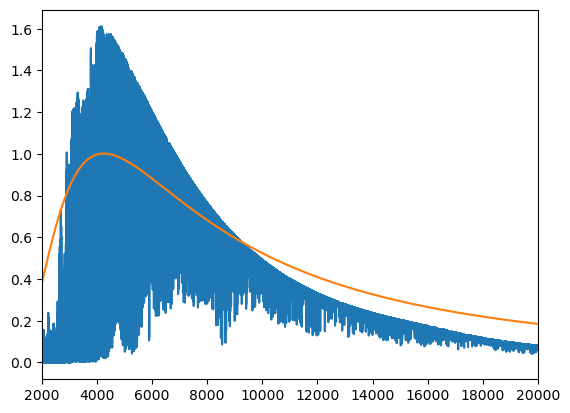

In [17]:
#make a BB spectrum:
bb = BlackBody(temperature=12000*u.K)
wav = np.arange(1000, 20000) * u.AA
flux = bb(wav)

#get data from BT-Settl:

btstl   = np.loadtxt('btsettl_model.dat')
btstl_w, btstl_f = btstl[:,0], btstl[:,1]



plt.plot( btstl_w, btstl_f/btstl_f[ np.min(np.where( btstl_w >=4400 ) ) ])
plt.plot( wav, flux/flux[ np.min( np.where( np.array(wav) >= 4400) ) ] )
plt.xlim(2e3, 2e4)

- what about the R ?

In [18]:
#compare three different resolutions for BTSettl:

R1 = 10
R2 = 100
R3 = 1000

w1 = np.zeros( 500 ) +500
w2 = np.zeros( 500 ) +500
w3 = np.zeros( 5000 ) +500

for i in range(1, len(w1) ):
    w1[i] = R1/(R1-1) * w1[i-1]

for i in range(1, len(w2) ):
    w2[i] = R2/(R2-1) * w2[i-1]

for i in range(1, len(w3) ):
    w3[i] = R3/(R3-1) * w3[i-1]

#btstl_w, btstl_f

#interpolate fluxes to the w_i array:

f1 = np.interp( w1, btstl_w,btstl_f )
f2 = np.interp( w2, btstl_w,btstl_f )
f3 = np.interp( w3, btstl_w,btstl_f )

(500.0, 20000.0)

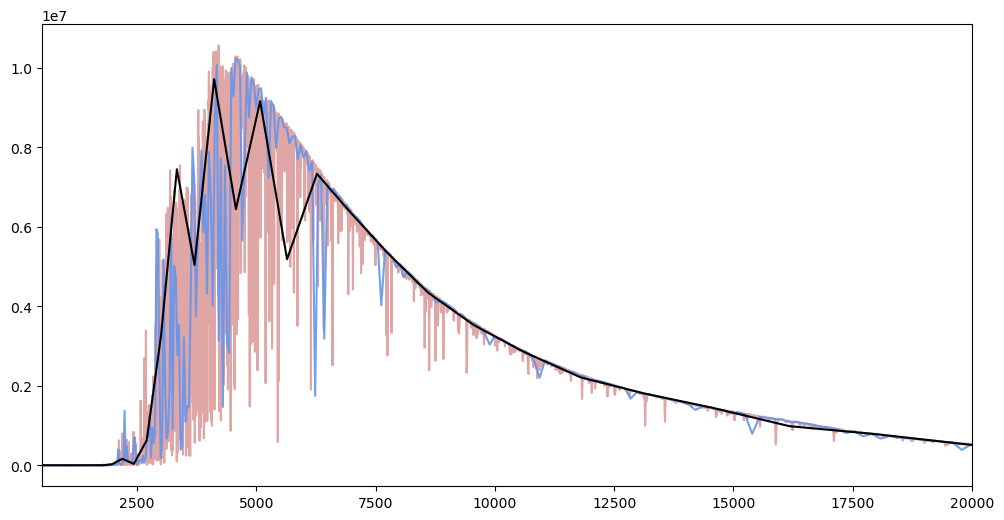

In [19]:
plt.figure( figsize = (12, 6))
plt.plot( w3,f3, color = 'firebrick', alpha = .4)
plt.plot( w2,f2, color = 'cornflowerblue', alpha = .9)
plt.plot( w1,f1, color = 'black')
plt.xlim(500, 2e4)